In [167]:
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [168]:
data = load_breast_cancer()
X, y = load_breast_cancer(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

split = StratifiedShuffleSplit(train_size = 0.2, n_splits = 5, random_state = 42)
for (idx_train, idx_test) in split.split(X, y):
    X_train, X_test = X[idx_train], X[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]

([<matplotlib.axis.XTick at 0x119bf6990>,
 [Text(0, 0, 'malignant'), Text(1, 0, 'benign')])

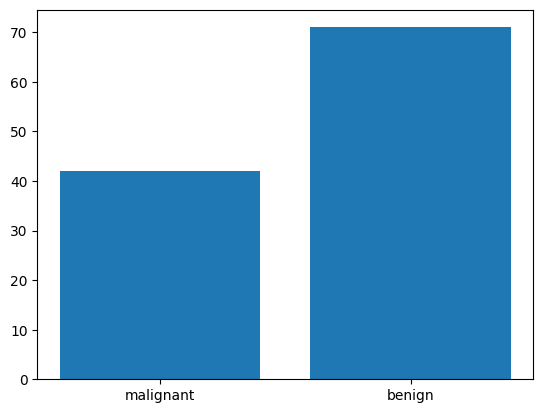

In [169]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.bincount(y_train)
positions = np.arange(len(counts))

plt.bar(positions, counts)
plt.xticks(positions, data.target_names)

In [170]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

X_scaled_train

array([[ 1.95441188,  0.50505365,  1.98870921, ...,  1.44456268,
        -0.55028814,  0.22391663],
       [-0.0604597 , -0.57649897, -0.14438183, ..., -1.01376973,
        -0.45134756, -0.89515802],
       [-1.30301388, -0.68082196, -1.30392374, ..., -0.92161745,
         0.02580138, -0.16417996],
       ...,
       [ 1.04756953, -0.81282248,  1.00480317, ...,  0.47118572,
        -0.10984297, -0.28475366],
       [-0.84418769, -0.71701565, -0.79125691, ..., -0.46041159,
        -1.06573666,  0.89790477],
       [-0.48685577, -1.28546949, -0.55606884, ..., -1.28889317,
        -0.86945131, -0.70440666]], shape=(113, 30))

In [171]:
classifier = KNeighborsClassifier()
classifier.fit(X_scaled_train, y_train)

prediction = classifier.predict(X_scaled_test)
score = accuracy_score(y_test, prediction)

score

0.9473684210526315

In [76]:
data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [172]:
matrix = confusion_matrix(y_test, prediction)
matrix

array([[151,  19],
       [  5, 281]])

In [77]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2)

for (train_idx, test_idx) in split.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

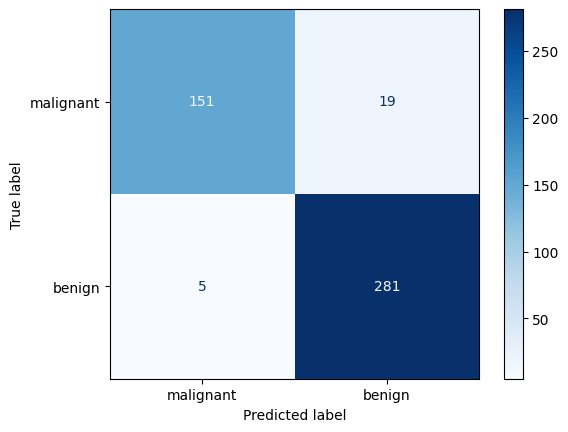

In [173]:
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['malignant', 'benign'])
disp.plot(cmap='Blues')

([<matplotlib.axis.XTick at 0x11b04b250>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

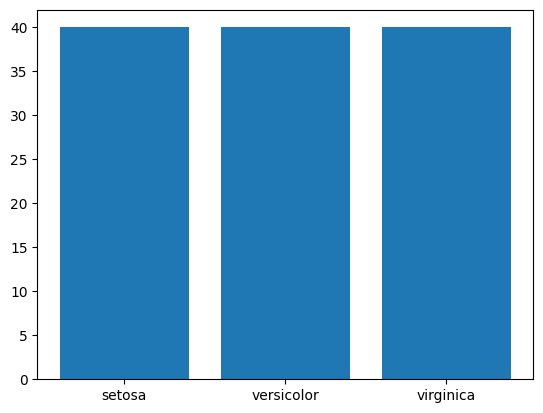

In [78]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.bincount(y_train)
positions = np.arange(len(counts))

plt.bar(positions, counts)
plt.xticks(positions, data.target_names)

([<matplotlib.axis.XTick at 0x11b09bc50>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

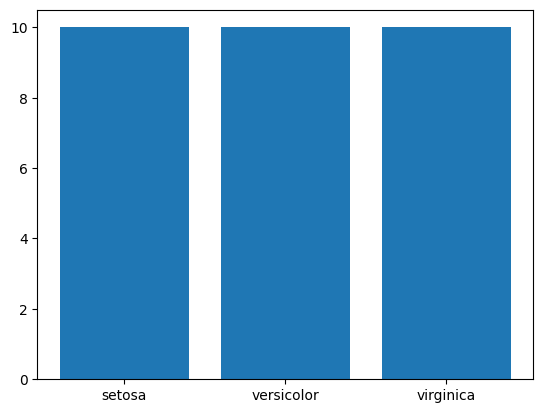

In [79]:
counts = np.bincount(y_test)
plt.bar(positions, counts)
plt.xticks(positions, data.target_names)

In [80]:
from sklearn.datasets import fetch_openml, clear_data_home
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

data = fetch_openml('car', as_frame=True).frame

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


In [81]:
columns_to_encode = ['lug_boot', 'safety']

encoder = OrdinalEncoder(
    categories = [
        ['small', 'med', 'big'],
        ['low', 'med', 'high'],
    ]
)

data[columns_to_encode] = encoder.fit_transform(data[columns_to_encode])
data

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,0.0,0.0,P
1,vhigh,vhigh,2,2,0.0,1.0,P
2,vhigh,vhigh,2,2,0.0,2.0,P
3,vhigh,vhigh,2,2,1.0,0.0,P
4,vhigh,vhigh,2,2,1.0,1.0,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,1.0,1.0,N
1724,low,low,5more,more,1.0,2.0,N
1725,low,low,5more,more,2.0,0.0,P
1726,low,low,5more,more,2.0,1.0,N


In [85]:
encoder.inverse_transform(data[columns_to_encode])

array([['small', 'low'],
       ['small', 'med'],
       ['small', 'high'],
       ...,
       ['big', 'low'],
       ['big', 'med'],
       ['big', 'high']], shape=(1728, 2), dtype=object)

In [86]:
adult = fetch_openml('adult', as_frame=True).frame
adult

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,2,United-States,<=50K
48838,4,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,2,United-States,<=50K
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,3,United-States,<=50K
48840,2,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,2,0,2,United-States,<=50K


In [87]:
adult.occupation.value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [88]:
import pandas as pd

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_values = encoder.fit_transform(adult[['occupation', 'race']])
encoded_values

array([[1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(48842, 20))

In [89]:
new_values = encoder.get_feature_names_out(['occupation', 'race'])
new_values

array(['occupation_Adm-clerical', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupation_Tech-support', 'occupation_Transport-moving',
       'occupation_nan', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other',
       'race_White'], dtype=object)

In [90]:
df_encoded = pd.DataFrame(encoded_values, columns=new_values, index=adult.index)
df_encoded

,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
48839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48840,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [91]:
df_final = pd.concat(
    [adult.drop(columns=['occupation', 'race']), df_encoded], axis=1
)
df_final

,age,workclass,fnlwgt,education,education-num,marital-status,relationship,sex,capitalgain,capitalloss,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,2,State-gov,77516,Bachelors,13,Never-married,Not-in-family,Male,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,Private,215646,HS-grad,9,Divorced,Not-in-family,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,Private,234721,11th,7,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Wife,Female,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Not-in-family,Female,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48838,4,NaN,321403,HS-grad,9,Widowed,Other-relative,Male,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48840,2,Private,83891,Bachelors,13,Divorced,Own-child,Male,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [92]:
y = df_final['class']
X = df_final.drop(['class'], axis=1)

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

38131    <=50K
15596    <=50K
25380    <=50K
23380     >50K
10105    <=50K
         ...  
39033    <=50K
5716     <=50K
17870    <=50K
15561     >50K
19843    <=50K
Name: class, Length: 9769, dtype: category
Categories (2, object): ['<=50K', '>50K']

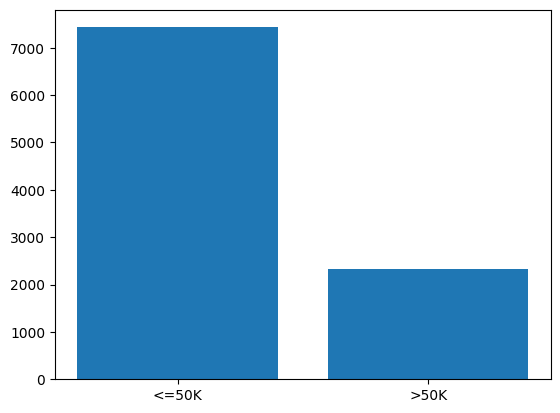

In [103]:
split = StratifiedShuffleSplit(n_splits=5, train_size=0.2, random_state=42)

for (idx_train, idx_test) in split.split(X, y):
    X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
    y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]


y_train_codes = y_train.astype('category').cat.codes
y_test_codes = y_test.astype('category').cat.codes

counts = np.bincount(y_train_codes)
positions = np.arange(len(counts))

plt.bar(positions, counts)
plt.xticks(positions, y_train.astype('category').cat.categories)
plt.show()

In [110]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
category_cols = X_train.select_dtypes(include=['object']).columns

numeric_cols

Index(['fnlwgt', 'education-num', 'occupation_Adm-clerical',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'occupation_nan',
       'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black',
       'race_Other', 'race_White'],
      dtype='object')

In [115]:
scaler = StandardScaler()
# X_scaled_train = scaler.fit_transform(numeric_cols)
# X_scaled_test = scaler.transform(X_test)

classifier = KNeighborsClassifier()

classifier.fit(X_train, y_test)

ValueError: Input contains NaN

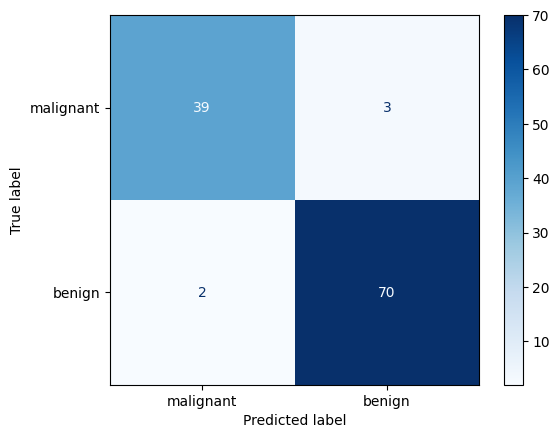